# Лабораторная работа №2

## Загрузка и подготовка данных

## Загрузка предобработанного датасета

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from scipy.stats import zscore

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from math import sqrt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

In [80]:
data = pd.read_csv('../data/final_data_diamonds.csv')
data.drop(['Unnamed: 0'], axis=1, inplace=True)
data

,carat,cut,color,clarity,depth,table,price,x,y,z
0,-1.199341,4,5,1,-0.176252,-1.096824,326,-1.587838,-1.573374,-1.593630
1,-1.241582,3,5,2,-1.381332,1.591635,326,-1.641325,-1.699003,-1.766179
2,-1.199341,1,5,4,-3.437054,3.383941,327,-1.498691,-1.492612,-1.766179
3,-1.072620,3,1,3,0.461732,0.247406,334,-1.364972,-1.349036,-1.306050
4,-1.030379,1,0,1,1.099714,0.247406,335,-1.240166,-1.241354,-1.133502
...,...,...,...,...,...,...,...,...,...,...
53935,-0.164447,4,6,2,-0.672462,-0.200671,2757,0.016798,0.023908,-0.055076
53936,-0.164447,1,6,2,0.957939,-1.096824,2757,-0.036690,0.014935,0.103093
53937,-0.206688,2,6,2,0.745278,1.143559,2757,-0.063434,-0.047880,0.031198
53938,0.131237,3,2,1,-0.530687,0.247406,2757,0.373383,0.346954,0.290021


In [81]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  int64  
 2   color    53940 non-null  int64  
 3   clarity  53940 non-null  int64  
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 4.1 MB


In [82]:
data.describe()

,carat,cut,color,clarity,depth,table,price,x,y,z
count,5.394000e+04,53940.000000,53940.000000,53940.000000,53940.000000,5.394000e+04,53940.000000,5.394000e+04,5.394000e+04,5.394000e+04
mean,-6.744492e-17,2.904097,3.405803,3.051020,0.000002,1.070688e-15,3932.799722,-8.132826e-08,-6.574655e-08,6.312710e-08
std,1.000009e+00,1.116600,1.701105,1.647136,1.000009,1.000009e+00,3989.439738,1.000009e+00,1.000009e+00,1.000009e+00
min,-1.262702e+00,0.000000,0.000000,0.000000,-4.783908,-6.025664e+00,326.000000,-5.109120e+00,-5.144824e+00,-5.087731e+00
25%,-8.402965e-01,2.000000,2.000000,2.000000,-0.530687,-6.487472e-01,950.000000,-9.103249e-01,-9.093354e-01,-9.034376e-01
50%,-2.066879e-01,3.000000,3.000000,3.000000,0.036408,-2.006708e-01,2401.000000,-2.777578e-02,-2.095931e-02,-1.193879e-02
75%,5.114018e-01,4.000000,5.000000,4.000000,0.532618,6.954821e-01,5324.250000,7.210541e-01,7.238405e-01,7.213910e-01
max,5.918195e+00,4.000000,6.000000,7.000000,4.785839,6.072399e+00,18823.000000,4.465202e+00,7.256544e+00,7.220705e+00


## Выделение целевого признака и предикторов

In [83]:
y = data["price"]
X = data.drop(["price"], axis=1)
y

0         326
1         326
2         327
3         334
4         335
         ... 
53935    2757
53936    2757
53937    2757
53938    2757
53939    2757
Name: price, Length: 53940, dtype: int64

In [84]:
X

,carat,cut,color,clarity,depth,table,x,y,z
0,-1.199341,4,5,1,-0.176252,-1.096824,-1.587838,-1.573374,-1.593630
1,-1.241582,3,5,2,-1.381332,1.591635,-1.641325,-1.699003,-1.766179
2,-1.199341,1,5,4,-3.437054,3.383941,-1.498691,-1.492612,-1.766179
3,-1.072620,3,1,3,0.461732,0.247406,-1.364972,-1.349036,-1.306050
4,-1.030379,1,0,1,1.099714,0.247406,-1.240166,-1.241354,-1.133502
...,...,...,...,...,...,...,...,...,...
53935,-0.164447,4,6,2,-0.672462,-0.200671,0.016798,0.023908,-0.055076
53936,-0.164447,1,6,2,0.957939,-1.096824,-0.036690,0.014935,0.103093
53937,-0.206688,2,6,2,0.745278,1.143559,-0.063434,-0.047880,0.031198
53938,0.131237,3,2,1,-0.530687,0.247406,0.373383,0.346954,0.290021


## Разделние выборки

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=217)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((43152, 9), (43152,), (10788, 9), (10788,))

# Решение задачи регрессии

## Вспомогательные функции

In [86]:
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    stats = {
        'R^2': r2,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }
        
    return stats

## линейная регрессия

In [87]:
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_pred

array([1491.95893909, 1883.04718843,  130.53546268, ..., 5119.70206061,
       -506.21997778,  949.81840112], shape=(10788,))

In [88]:
print(calculate_metrics(y_test, y_pred))

{'R^2': 0.908996942900378, 'MSE': 1459016.4769430882, 'RMSE': 1207.8975440587203, 'MAE': 801.7764849426568, 'MAPE': 0.4421530193737189}


In [89]:
mlrm = LinearRegression().fit(X_train, y_train)
y_pred = mlrm.predict(X_test)
mlrm

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<Axes: xlabel='carat'>

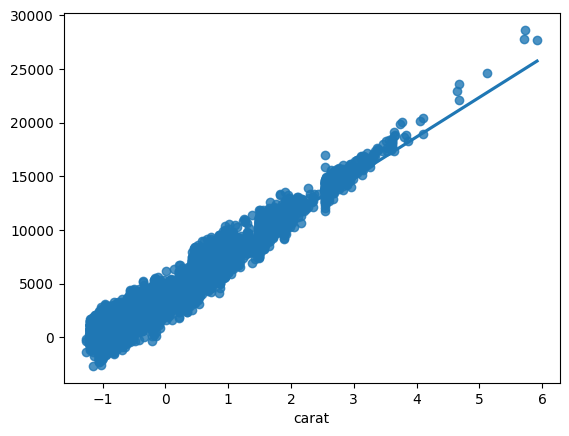

In [90]:
sns.regplot(x=X_test["carat"], y=y_pred)

<Axes: xlabel='carat'>

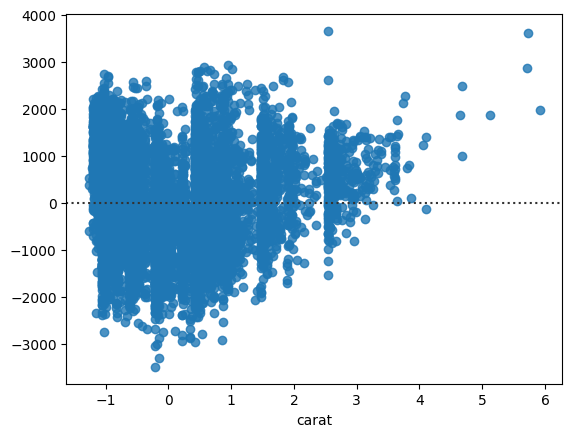

In [91]:
sns.residplot(x=X_test["carat"], y=y_pred)

In [92]:
col_list = X.columns
for x in col_list:
  print(x)
  loop_lm = LinearRegression().fit(X_train[[x]], y_train)
  print('The intercept = ', loop_lm.intercept_, ' и coefficient = ', loop_lm.coef_)
  Yhat_loop_lm = loop_lm.predict(X_test[[x]])
  print('Mean Squared Error = ', mean_squared_error(y_test, Yhat_loop_lm), ' и R^2= ', r2_score(y_test,Yhat_loop_lm))
  print('')

carat
The intercept =  3926.9013703826054  и coefficient =  [3675.14587943]
Mean Squared Error =  2427866.427959557  и R^2=  0.8485669828508201

cut
The intercept =  4484.71569964789  и coefficient =  [-188.56463177]
Mean Squared Error =  15982640.548294945  и R^2=  0.00311670676495579

color
The intercept =  5315.06890699782  и coefficient =  [-405.23878826]
Mean Squared Error =  15570870.459260464  и R^2=  0.028799992400518115

clarity
The intercept =  5039.017565472354  и coefficient =  [-361.71105793]
Mean Squared Error =  15741805.324871512  и R^2=  0.01813829283691193

depth
The intercept =  3936.775762310558  и coefficient =  [-37.12558218]
Mean Squared Error =  16029472.69238908  и R^2=  0.0001956511425916796

table
The intercept =  3936.2621106511792  и coefficient =  [503.15350866]
Mean Squared Error =  15758869.044899436  и R^2=  0.017073979504901637

x
The intercept =  3926.6312499854816  и coefficient =  [3521.76147903]
Mean Squared Error =  3425756.023220257  и R^2=  0.78

In [93]:
print('intercept = ', lr.intercept_, ' и coefficients = ', lr.coef_)

intercept =  961.586244706084  и coefficients =  [ 5146.15686193   122.1126433    322.54703704   496.33209546
  -106.97811486   -52.61622302 -1641.50501419   735.04340374
  -108.2189891 ]


/tmp/ipykernel_12018/502106734.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 =  sns.distplot(y_test, hist=False, color='Red', label='Actual weight')


/tmp/ipykernel_12018/502106734.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, hist=False, color='Blue', ax=ax1, label='Predicted weight')


<Axes: xlabel='price', ylabel='Density'>

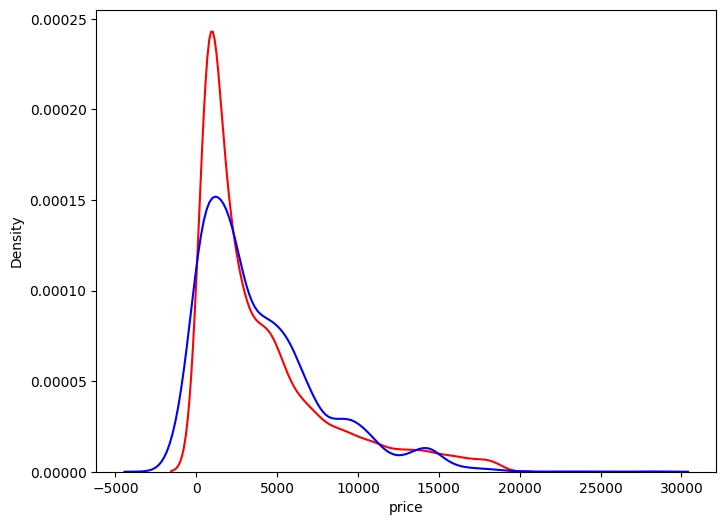

In [94]:
y_pred = mlrm.predict(X_test)

plt.figure(figsize=(8,6))

ax1 =  sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred, hist=False, color='Blue', ax=ax1, label='Predicted weight')

In [95]:
print('Mean Squared Error = ', mean_squared_error(y_test, y_pred), ' и R^2 = ', r2_score(y_test, y_pred))

Mean Squared Error =  1459016.4769430882  и R^2 =  0.908996942900378


In [96]:
def PlotPolly(model, independent_variable, dependent_variable, Name):
    x_new = np.linspace(min(independent_variable)*0.98, max(independent_variable)*1.01, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variable, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for price')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of diamond')

    plt.show()

In [97]:
pol = np.polyfit(X_train['carat'], y_train, 5)
func = np.poly1d(pol)
print(func)

       5         4         3        2
13.25 x - 90.48 x - 142.8 x + 1020 x + 3614 x + 3285


       5         4         3        2
11.15 x - 68.96 x - 199.2 x + 1012 x + 3717 x + 3316


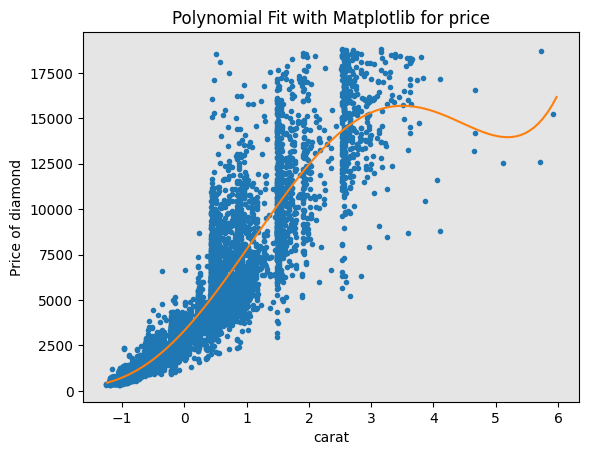

/tmp/ipykernel_12018/1146697002.py:2: RankWarning: Polyfit may be poorly conditioned
  pol_loop = np.polyfit(X_test[x], y_test, 5)


        5         4         3       2
-3.834 x - 6.667 x + 36.63 x + 370 x - 879.4 x + 4306


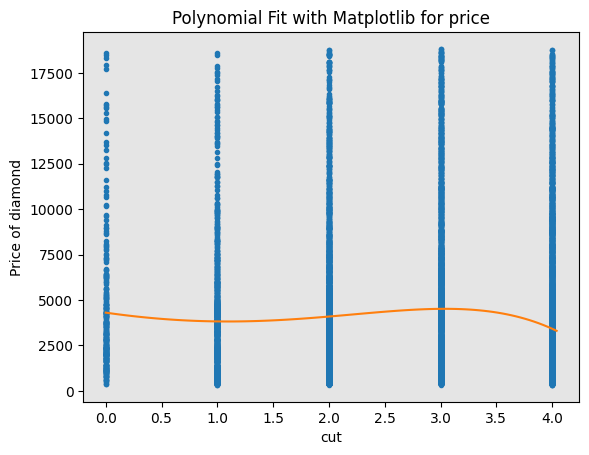

       5         4         3         2
4.221 x - 59.24 x + 303.2 x - 688.8 x + 196.4 x + 5267


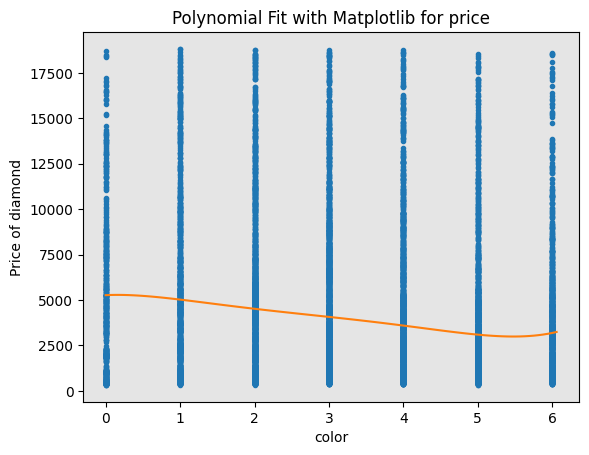

       5         4        3        2
15.35 x - 265.5 x + 1616 x - 4088 x + 3491 x + 4217


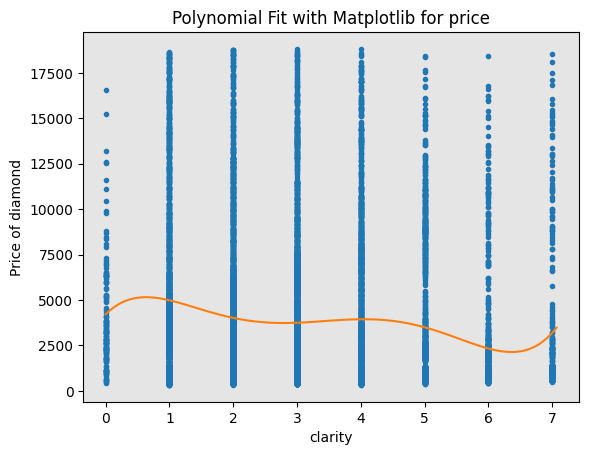

       5         4         3         2
1.812 x - 11.32 x - 29.45 x + 204.9 x + 16.63 x + 3768


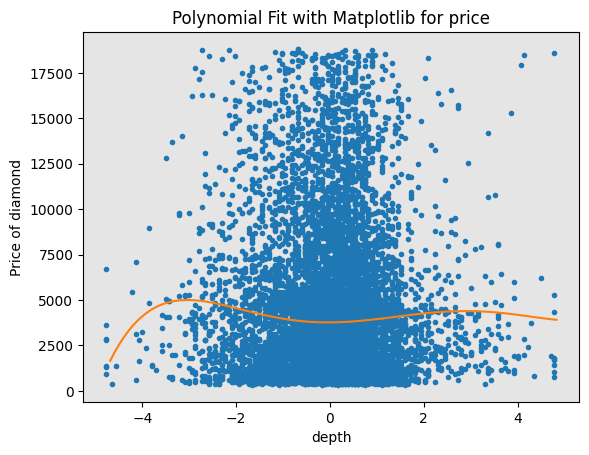

        5         4         3         2
-3.553 x + 41.19 x - 109.5 x - 227.4 x + 879.1 x + 4090


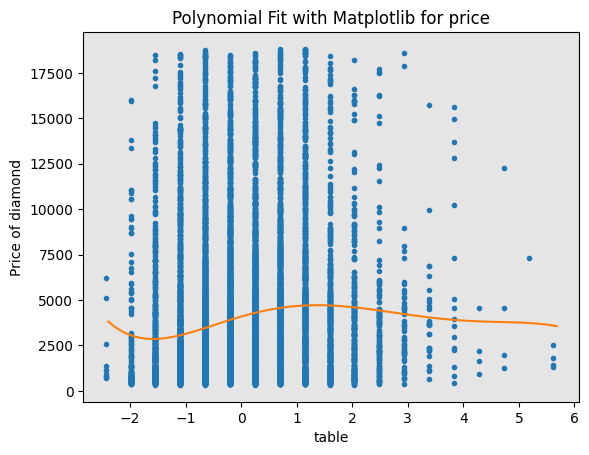

       5         4         3        2
2.162 x - 167.5 x + 109.1 x + 1626 x + 3106 x + 2665


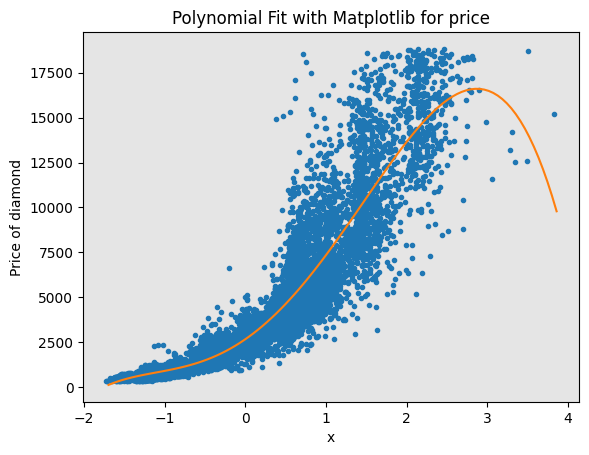

       5         4         3        2
27.63 x - 249.9 x + 70.41 x + 1835 x + 3126 x + 2591


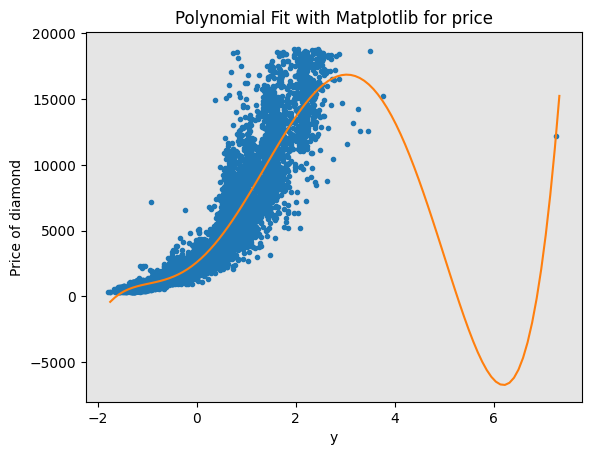

       5        4         3        2
5.077 x - 43.7 x - 207.8 x + 1419 x + 3551 x + 2710


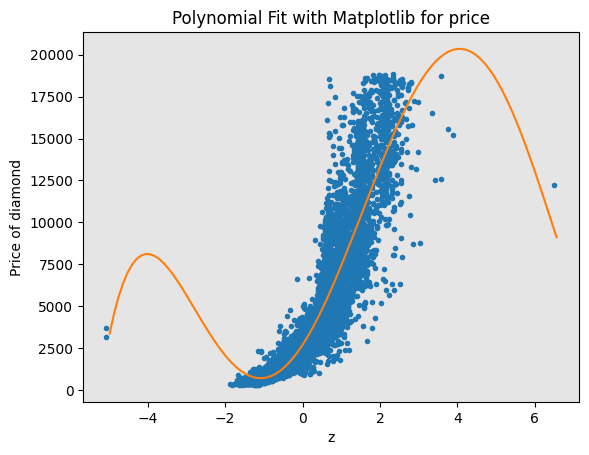

In [98]:
for x in X.columns:
  pol_loop = np.polyfit(X_test[x], y_test, 5)
  func_loop = np.poly1d(pol_loop)
  print(func_loop)
  plt.figure()
  PlotPolly(func_loop, X_test[x], y_test, Name=x)
  plt.show()

In [99]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [100]:
X_polF = data[X.columns]

In [101]:
Input = [('polynomial', PolynomialFeatures(degree=2, include_bias=False)), ('model', LinearRegression()) ]

In [102]:
pipe = Pipeline(Input)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomial', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [103]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomial', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [104]:
y_pred = pipe.predict(X_test)
y_pred

array([1218.32973934,  824.43021211,  284.03669201, ..., 5240.12674812,
        910.71344092,  941.96067704], shape=(10788,))

/tmp/ipykernel_12018/290870963.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax2 = sns.distplot(y_test, hist=False, color='Red', label='Actual values')
/tmp/ipykernel_12018/290870963.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, hist=False, color='Green', label='Predicte

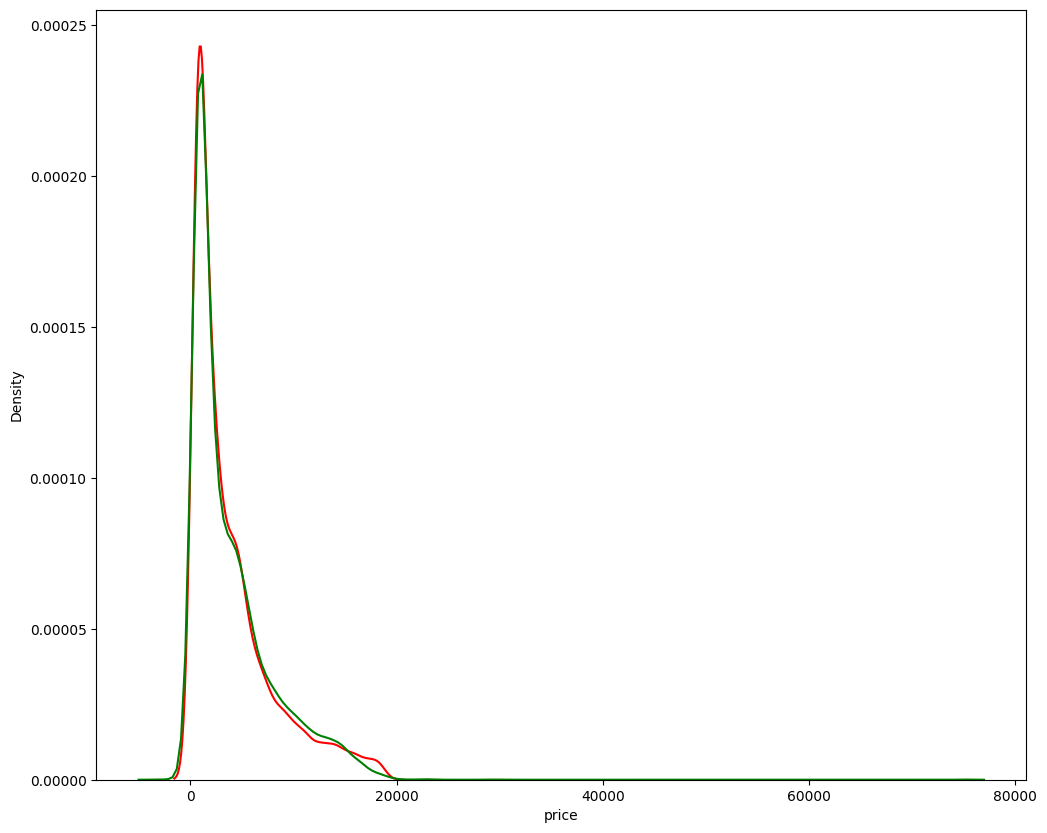

In [105]:
plt.figure(figsize=(12,10))
ax2 = sns.distplot(y_test, hist=False, color='Red', label='Actual values')
sns.distplot(y_pred, hist=False, color='Green', label='Predicted values')
plt.show()

In [106]:
print(calculate_metrics(y_test, y_pred))

{'R^2': 0.94174802619671, 'MSE': 933931.1480538193, 'RMSE': 966.401132063606, 'MAE': 454.3135172659866, 'MAPE': 0.19701028715498364}


<Axes: xlabel='carat'>

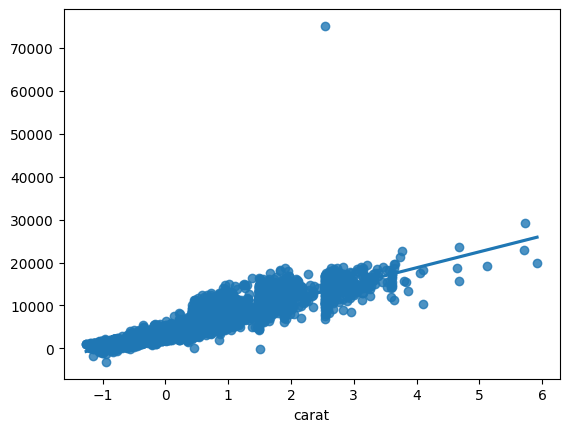

In [107]:
sns.regplot(x=X_test["carat"], y=y_pred)

<Axes: xlabel='carat'>

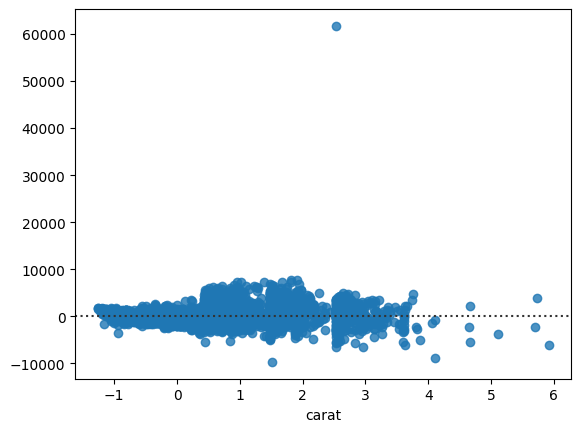

In [108]:
sns.residplot(x=X_test["carat"], y=y_pred)

In [109]:
print(calculate_metrics(y_train, pipe.predict(X_train)))
print(calculate_metrics(y_test, pipe.predict(X_test)))

{'R^2': 0.9638583699538332, 'MSE': 574143.6405797611, 'RMSE': 757.7226673260878, 'MAE': 457.39053999248637, 'MAPE': 0.1954194207355665}
{'R^2': 0.94174802619671, 'MSE': 933931.1480538193, 'RMSE': 966.401132063606, 'MAE': 454.3135172659866, 'MAPE': 0.19701028715498364}


In [110]:
lr = LinearRegression().fit(X_train, y_train)

print(calculate_metrics(y_train, lr.predict(X_train)))
print(calculate_metrics(y_test, lr.predict(X_test)))

{'R^2': 0.9086499186060193, 'MSE': 1451181.5939624524, 'RMSE': 1204.6499881552536, 'MAE': 801.9427262009584, 'MAPE': 0.4355424099625993}
{'R^2': 0.908996942900378, 'MSE': 1459016.4769430882, 'RMSE': 1207.8975440587203, 'MAE': 801.7764849426568, 'MAPE': 0.4421530193737189}


In [111]:
parameters = {'alpha': np.arange(0, 1, 0.1)}    

In [112]:
ridge = Ridge(alpha=0.9).fit(X_train, y_train)
y_pred = ridge.predict(X_test)

print(calculate_metrics(y_train, ridge.predict(X_train)))
print(calculate_metrics(y_test, ridge.predict(X_test)))

{'R^2': 0.9086498634713523, 'MSE': 1451182.4698282722, 'RMSE': 1204.650351690594, 'MAE': 802.0186665909283, 'MAPE': 0.43560421140234}
{'R^2': 0.9089939021527622, 'MSE': 1459065.2280621722, 'RMSE': 1207.9177240450495, 'MAE': 801.8611990350349, 'MAPE': 0.4422210651308942}


In [113]:
lasso = Lasso(alpha=0.9).fit(X_train, y_train)
y_pred = ridge.predict(X_test)

print(calculate_metrics(y_train, lasso.predict(X_train)))
print(calculate_metrics(y_test, lasso.predict(X_test)))

{'R^2': 0.9086018726893438, 'MSE': 1451944.8483447204, 'RMSE': 1204.9667415927795, 'MAE': 802.6075100088107, 'MAPE': 0.43589773174321883}
{'R^2': 0.9088808888726622, 'MSE': 1460877.1258492863, 'RMSE': 1208.667500121223, 'MAE': 802.6952795602318, 'MAPE': 0.44264504996052945}
